In [1]:
# Cell 1 — Load model and test data

import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("training_ready.csv")

# Updated features (based on new file)
X = df[[
    "Temperature",
    "Elevation",
    "Population Density",
    "Energy Consumption",
    "AQI",
    "Urban Greenness Ratio",
    "Wind Speed",
    "Humidity",
    "Annual Rainfall"
]]

y = df["severity"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Load trained model
with open("uhi_model.pkl", "rb") as f:
    model = pickle.load(f)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9977
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13402
           1       0.98      1.00      0.99      1861
           2       1.00      0.90      0.95       349

    accuracy                           1.00     15612
   macro avg       0.99      0.97      0.98     15612
weighted avg       1.00      1.00      1.00     15612



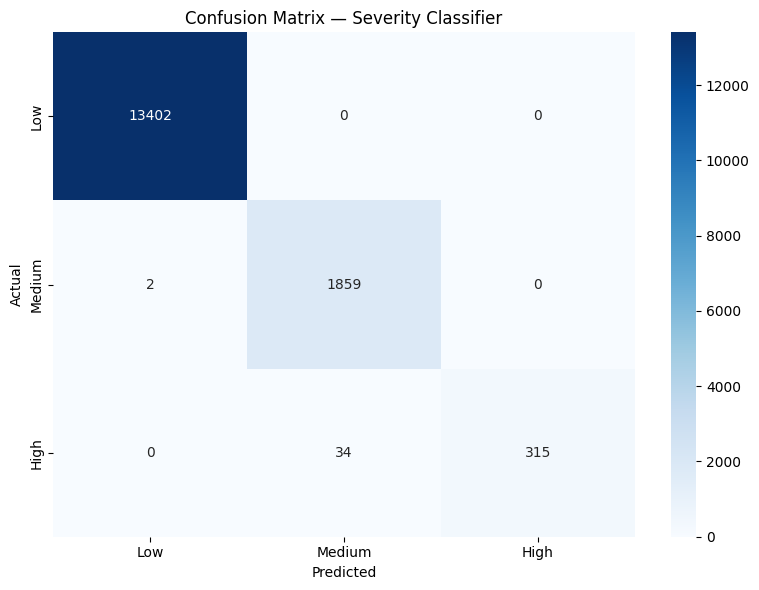

In [2]:
# Cell 2 — Confusion matrix (save this for poster)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Labels
labels = ["Low", "Medium", "High"]

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix — Severity Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

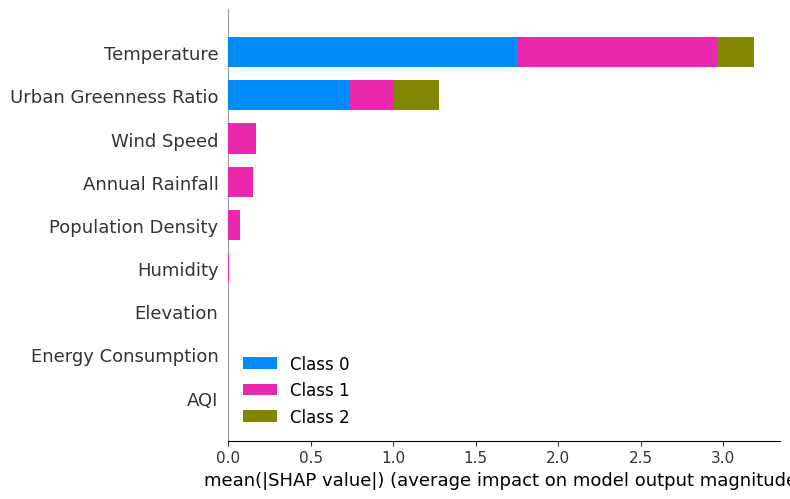

SHAP plot saved


In [3]:
# Cell 3 — SHAP feature importance (save this for poster)
# Cell 3 — SHAP feature importance (updated)

import shap

# Ensure correct feature order (very important)
X_sample = X_test[model.feature_names_in_].iloc[:500]

# Create explainer
explainer = shap.Explainer(model, X_sample)

# Compute SHAP values
shap_values = explainer(X_sample)

# Plot
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)

plt.savefig("shap_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print("SHAP plot saved")